In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%load_ext watermark
%watermark

The watermark extension is already loaded. To reload it, use:
  %reload_ext watermark
2026-03-18T00:29:42-06:00

CPython 3.6.13
IPython 7.16.3

compiler   : MSC v.1916 64 bit (AMD64)
system     : Windows
release    : 10
machine    : AMD64
processor  : AMD64 Family 25 Model 33 Stepping 2, AuthenticAMD
CPU cores  : 12
interpreter: 64bit


In [25]:
df = pd.read_csv("data/boston_dataset.csv")
df.head()

df = df.rename(columns={ 
    "TOWN":"Ciudad",
    "CRIM":"Indice_Criminalidad",
    "ZN":"PCT Zona_Residencial",
    "INDUS": "PCT_Zona_Industrial",
    "CHAS": "Rio_Charles",
    "NOX": "Oxido_Nitroso_PPM",
    "RM": "N_Habitaciones_Medio",
    "AGE": "PCT_Casas_405",
    "DIS": "Distancia_Centro_Empleo",
    "RAD": "Dis_Autopistas",
    "TAX": "Carga_Fiscal",
    "PTRATIO": "Ratio_Profesores",
    "B": "PCT_Negra",
    "MEDV": "Valor_Mediano",
    "LSTAT": "PCT_Clase_Baja"})

df.head()

,Ciudad,LON,LAT,Valor_Mediano,Indice_Criminalidad,PCT Zona_Residencial,PCT_Zona_Industrial,Rio_Charles,Oxido_Nitroso_PPM,N_Habitaciones_Medio,PCT_Casas_405,Distancia_Centro_Empleo,Dis_Autopistas,Carga_Fiscal,Ratio_Profesores,PCT_Negra,PCT_Clase_Baja
0,Nahant,-70.955,42.2550,24.0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98
1,Swampscott,-70.950,42.2875,21.6,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14
2,Swampscott,-70.936,42.2830,34.7,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03
3,Marblehead,-70.928,42.2930,33.4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94
4,Marblehead,-70.922,42.2980,36.2,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33


In [26]:
%matplotlib notebook

In [27]:
import matplotlib.pyplot as plt

<IPython.core.display.Javascript object>


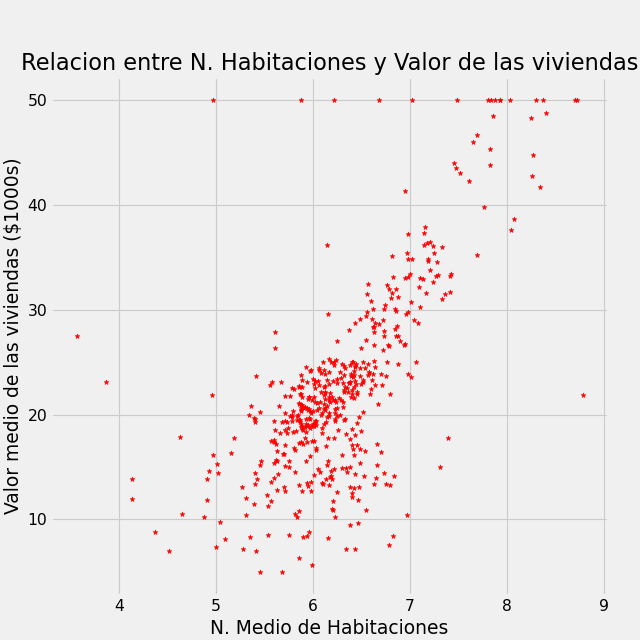

Text(0, 0.5, 'Valor medio de las viviendas ($1000s)')

In [28]:
df.plot.scatter(x="N_Habitaciones_Medio", y="Valor_Mediano", marker="*", color="red")
plt.title("Relacion entre N. Habitaciones y Valor de las viviendas")
plt.xlabel("N. Medio de Habitaciones")
plt.ylabel("Valor medio de las viviendas ($1000s)")

In [29]:
import matplotlib as mpl

mpl.rcParams['figure.figsize'] = (8,8)

In [30]:
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'seaborn',
 'seaborn-bright',
 'seaborn-colorblind',
 'seaborn-dark',
 'seaborn-dark-palette',
 'seaborn-darkgrid',
 'seaborn-deep',
 'seaborn-muted',
 'seaborn-notebook',
 'seaborn-paper',
 'seaborn-pastel',
 'seaborn-poster',
 'seaborn-talk',
 'seaborn-ticks',
 'seaborn-white',
 'seaborn-whitegrid',
 'tableau-colorblind10']

In [31]:
plt.style.use("fivethirtyeight")

<IPython.core.display.Javascript object>


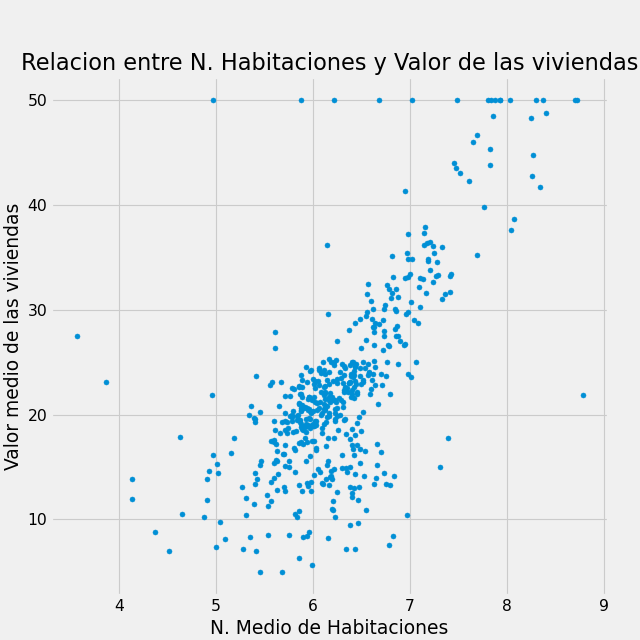

Text(0, 0.5, 'Valor medio de las viviendas')

In [32]:
df.plot.scatter(x="N_Habitaciones_Medio", y="Valor_Mediano")
plt.title("Relacion entre N. Habitaciones y Valor de las viviendas")
plt.xlabel("N. Medio de Habitaciones")
plt.ylabel("Valor medio de las viviendas")

In [33]:
from ipywidgets import interact

In [34]:
@interact(col1=df.columns.tolist())
def grafico_variable(col1):
    df.plot.scatter(x=col1, y="Valor_Mediano")
    plt.title("{} vs Valor Mediano".format(col1))

interactive(children=(Dropdown(description='col1', options=('Ciudad', 'LON', 'LAT', 'Valor_Mediano', 'Indice_C…

In [35]:
%matplotlib notebook

<IPython.core.display.Javascript object>


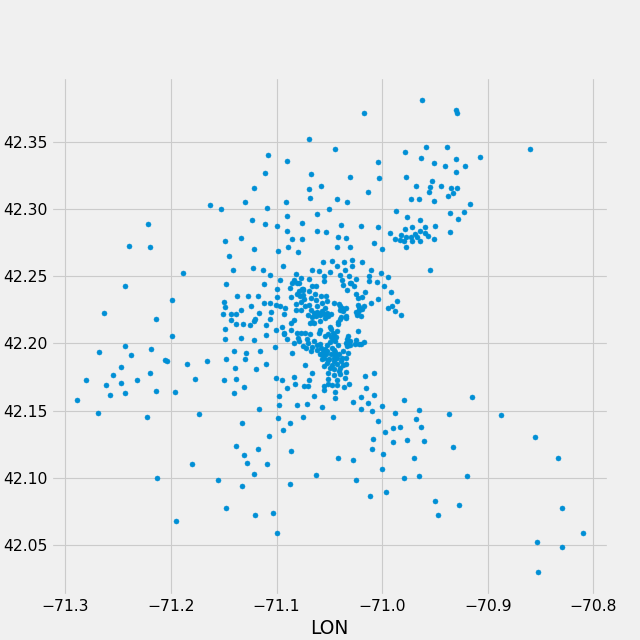

<AxesSubplot:xlabel='LON', ylabel='LAT'>

In [36]:
df.plot.scatter(x="LON", y="LAT")

In [38]:
import cartopy.crs as ccrs

from cartopy.io import img_tiles

<IPython.core.display.Javascript object>


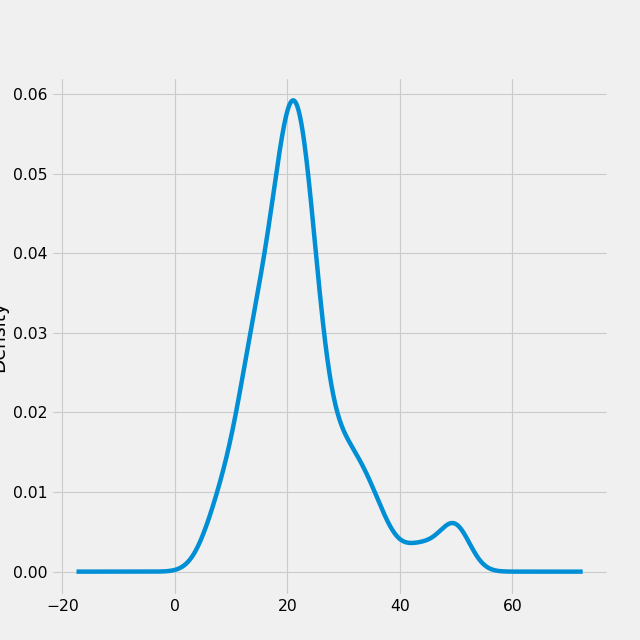

<AxesSubplot:ylabel='Density'>

In [39]:
df.Valor_Mediano.plot.kde()

In [47]:
primer_quintil = df.Valor_Mediano.quantile(0.2)

In [48]:
primer_quintil 

15.3

In [49]:
cuarto_quintil = df.Valor_Mediano.quantile(0.8)
cuarto_quintil

28.2

<IPython.core.display.Javascript object>


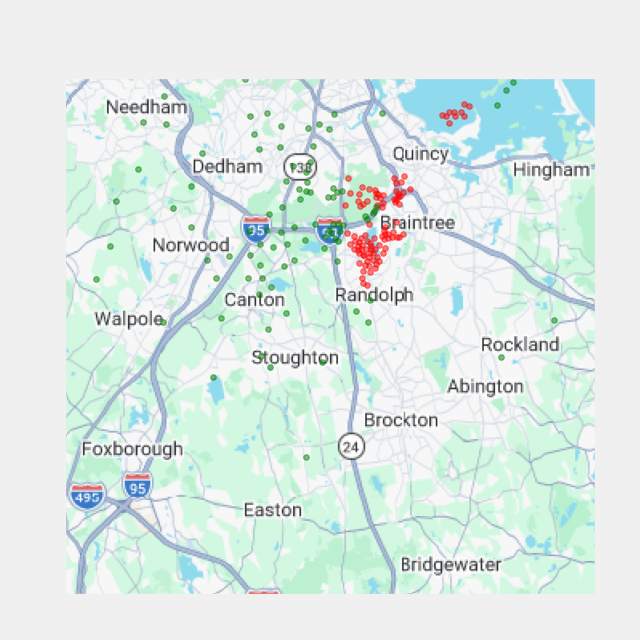

In [53]:
imagery = img_tiles.GoogleTiles()

ax = plt.axes(projection=imagery.crs)

limites_mapa = (-71.38, -70.77, 42.03, 42.47)

ax.set_extent(limites_mapa)

ax.add_image(imagery,10)

df_primer_qt = df[df.Valor_Mediano < primer_quintil]
df_tercer_qt = df[df.Valor_Mediano > cuarto_quintil]


plt.plot(df_primer_qt.LON, df_primer_qt.LAT, transform=ccrs.Geodetic(), marker=".", markersize=10, color="red", 
         linewidth=0, alpha=0.5)

plt.plot(df_tercer_qt.LON, df_tercer_qt.LAT, transform=ccrs.Geodetic(), marker=".", markersize=10, color="green", 
         linewidth=0, alpha=0.5)

plt.show()